# ANIP - Tache 1 : Reconnaissance Faciale Robuste
## Face Matching/Verification - Version V7 FaceNet (VGGFace2)

**Pourquoi V7 est un changement de paradigme :**

| Version | Backbone | Entraîné sur | Nb visages vus | Résultat |
|---|---|---|---|---|
| V1→V6 | MobileNetV2 | ImageNet (chiens, chats, voitures...) | 0 visage | Recall=40% |
| **V7** | **InceptionResnetV1** | **VGGFace2 (3.3M visages, 9000 personnes)** | **3.3M** | **à mesurer** |

MobileNetV2 ne sait pas ce qu'est une identité faciale. InceptionResnetV1 a été entraîné
spécifiquement pour distinguer des visages — il connaît déjà les traits discriminants
(forme des yeux, nez, mâchoire, proportions) avant même qu'on lui montre une seule image.

**Architecture V7 :**
- **Backbone** : InceptionResnetV1 (VGGFace2) → embeddings 512-dim
- **Fine-tuning** : tête légère Dense(256)→BN→Dropout→Dense(128)→L2 + Triplet Loss (PyTorch)
- **Approche zero-shot** : testée d'abord (sans entraînement) car le backbone est déjà excellent
- **Pipeline** : TTA 3 vues + seuil F1-optimal + filtre anti-doublons (hérités de V5/V6)

**Installation requise :** `pip install facenet-pytorch torch torchvision`


## 1. Imports et Configuration


In [11]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
from collections import defaultdict
import cv2
from tqdm import tqdm
import warnings
import hashlib
warnings.filterwarnings('ignore')

# PyTorch + FaceNet
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from facenet_pytorch import InceptionResnetV1

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, classification_report,
    precision_recall_curve, f1_score
)

try:
    import imagehash
    from PIL import Image as PILImage
    IMAGEHASH_AVAILABLE = True
except ImportError:
    IMAGEHASH_AVAILABLE = False
    print('[WARN] pip install imagehash pour la détection de quasi-doublons')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
print(f'CUDA     : {torch.cuda.is_available()}')


[WARN] pip install imagehash pour la détection de quasi-doublons
PyTorch  : 2.11.0+cpu
Device   : cpu
CUDA     : False


In [12]:
# ── Chemins ──────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('.').resolve()
DATA_PATH = NOTEBOOK_DIR / 'anip-reconnaissance-faciale-estimation-ages-ocr' / 'dataset_tache_1' / 'dataset_tache_1'

if not DATA_PATH.exists():
    candidates = list(NOTEBOOK_DIR.rglob('dataset_tache_1'))
    if candidates:
        DATA_PATH = candidates[-1]
        print(f'Dossier trouve : {DATA_PATH}')
    else:
        raise FileNotFoundError(f'dataset_tache_1 introuvable sous {NOTEBOOK_DIR}')

TRAIN_PATH = DATA_PATH / 'train'
TEST_PATH  = DATA_PATH / 'test'

# ── Hyperparamètres ───────────────────────────────────────────────────────────
IMG_SIZE      = (160, 160)   # taille attendue par InceptionResnetV1
BATCH_SIZE    = 32
SEED          = 42
VAL_SIZE      = 0.2

# Fine-tuning (optionnel — le modèle zero-shot est déjà très bon)
FINE_TUNE          = True    # False = zero-shot pur (rapide, déjà excellent)
FT_EPOCHS_FROZEN   = 5       # backbone gelé, seule la tête apprend
FT_EPOCHS_UNFREEZE = 10      # fine-tuning des dernières couches du backbone
FT_LR_FROZEN       = 1e-3
FT_LR_UNFREEZE     = 1e-5
FT_UNFREEZE_LAST_N = 5       # nb de blocs InceptionResnet à dégeler

TRIPLET_MARGIN    = 0.2
TRAIN_TRIPLETS    = 8000
VAL_TRIPLETS      = 2000
HARD_RATIO_TRAIN  = 0.4
MINING_K          = 4
DROPOUT_RATE      = 0.5
EMBED_DIM         = 128      # dimension finale après la tête
TTA_N_VIEWS       = 3        # original + flip + luminosité

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Train : {TRAIN_PATH}')
print(f'Test  : {TEST_PATH}')
print(f'Fine-tuning activé : {FINE_TUNE}')


Train : C:\Users\Ibrahima\Documents\anip-age-estimation-kit\anip-reconnaissance-faciale-estimation-ages-ocr\dataset_tache_1\dataset_tache_1\train
Test  : C:\Users\Ibrahima\Documents\anip-age-estimation-kit\anip-reconnaissance-faciale-estimation-ages-ocr\dataset_tache_1\dataset_tache_1\test
Fine-tuning activé : True


## 2. Chargement des données


In [13]:
def _list_valid_jpgs(folder):
    exts = {'.jpg', '.jpeg', '.JPG', '.JPEG'}
    files = [p for p in folder.iterdir()
             if p.is_file() and p.suffix in exts
             and not p.name.startswith('.')]
    return sorted(files), 0


def parse_train_filename(filepath):
    parts = filepath.stem.split('_')
    return int(parts[0]), int(parts[1])


def load_train_data():
    train_images, _ = _list_valid_jpgs(TRAIN_PATH)
    data = []
    for img_path in train_images:
        try:
            person_id, photo_num = parse_train_filename(img_path)
            data.append({'filepath': str(img_path), 'person_id': person_id, 'photo_num': photo_num})
        except (ValueError, IndexError):
            pass
    return pd.DataFrame(data).sort_values(['person_id', 'photo_num']).reset_index(drop=True)


print('Chargement des données...')
df_train = load_train_data()
print(f'Images          : {len(df_train)}')
print(f'Personnes       : {df_train["person_id"].nunique()}')
print(df_train.groupby('person_id').size().describe())

person_ids = np.array(sorted(df_train['person_id'].unique()))
train_ids, val_ids = train_test_split(person_ids, test_size=VAL_SIZE, random_state=SEED)

df_train_split = df_train[df_train['person_id'].isin(train_ids)].reset_index(drop=True)
df_val_split   = df_train[df_train['person_id'].isin(val_ids)].reset_index(drop=True)

print(f'\nTrain : {len(train_ids)} identités | {len(df_train_split)} images')
print(f'Val   : {len(val_ids)} identités | {len(df_val_split)} images')


Chargement des données...
Images          : 4000
Personnes       : 2000
count    2000.0
mean        2.0
std         0.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max         2.0
dtype: float64

Train : 1600 identités | 3200 images
Val   : 400 identités | 800 images


## 3. Prétraitement des images (format FaceNet)


In [14]:
def load_image_facenet(image_path, augment=False, flip=False):
    """
    Charge une image et la prépare pour InceptionResnetV1.
    FaceNet attend des images en float32 dans [-1, 1] (normalisation fixe).
    Taille : 160×160×3.
    """
    try:
        img = cv2.imread(str(image_path))
        if img is None:
            raise ValueError(f'Illisible : {image_path}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        img = img.astype('float32')

        if augment:
            h, w = img.shape[:2]
            # Flip horizontal
            if np.random.rand() > 0.5:
                img = img[:, ::-1, :]
            # Rotation ±15°
            angle = np.random.uniform(-15.0, 15.0)
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR,
                                 borderMode=cv2.BORDER_REFLECT_101)
            # Zoom ±10%
            scale = np.random.uniform(0.90, 1.10)
            M2 = cv2.getRotationMatrix2D((w/2, h/2), 0, scale)
            img = cv2.warpAffine(img, M2, (w, h), flags=cv2.INTER_LINEAR,
                                 borderMode=cv2.BORDER_REFLECT_101)
            # Luminosité
            img = np.clip(img + np.random.uniform(-25.0, 25.0), 0.0, 255.0)
            # Flou gaussien 40% du temps
            if np.random.rand() > 0.6:
                k = np.random.choice([3, 5])
                img = cv2.GaussianBlur(img, (k, k), 0)

        if flip:
            img = img[:, ::-1, :]

        # Normalisation FaceNet : [0,255] → [-1, 1]
        img = (img - 127.5) / 128.0

        # HWC → CHW (format PyTorch)
        img = np.transpose(img, (2, 0, 1))
        return img.astype('float32')

    except Exception as e:
        print(f'  [WARN] {e}')
        return np.zeros((3, *IMG_SIZE), dtype='float32')


def load_image_tta(image_path, n_views=TTA_N_VIEWS):
    """
    Retourne la moyenne des embeddings sur n_views vues de la même image.
    Appelée APRÈS avoir le modèle — retourne ici les n images brutes.
    Vue 1 : originale | Vue 2 : flip | Vue 3 : luminosité +15
    """
    views = [load_image_facenet(image_path, augment=False, flip=False)]
    if n_views >= 2:
        views.append(load_image_facenet(image_path, augment=False, flip=True))
    if n_views >= 3:
        img = cv2.imread(str(image_path))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE)
            img = np.clip(img.astype('float32') + 15.0, 0.0, 255.0)
            img = (img - 127.5) / 128.0
            img = np.transpose(img, (2, 0, 1)).astype('float32')
            views.append(img)
    return views  # liste de tableaux CHW


print('Fonctions de prétraitement FaceNet prêtes.')
print(f'  Normalisation : [0,255] → [-1,1]  |  Format : CHW  |  Taille : {IMG_SIZE}')


Fonctions de prétraitement FaceNet prêtes.
  Normalisation : [0,255] → [-1,1]  |  Format : CHW  |  Taille : (160, 160)


## 4. Modèle FaceNet + Tête d'Embedding


In [15]:
class FaceEmbedder(nn.Module):
    """
    InceptionResnetV1 (VGGFace2, 512-dim) + tête légère → EMBED_DIM-dim L2-normalisé.

    Le backbone produit des embeddings de 512 dimensions déjà excellents.
    La tête Dense(256)→BN→Dropout→Dense(128)→L2 compresse vers EMBED_DIM
    et laisse de la place pour un fine-tuning sur le dataset spécifique.
    """
    def __init__(self, pretrained='vggface2', freeze_backbone=True):
        super().__init__()

        # Backbone pré-entraîné sur VGGFace2
        # classify=False → sortie 512-dim (embedding) au lieu des logits
        self.backbone = InceptionResnetV1(pretrained=pretrained, classify=False)

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Tête d'embedding adaptée au dataset
        self.head = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(256, EMBED_DIM),
        )

    def forward(self, x):
        # Backbone → 512-dim
        features = self.backbone(x)          # (B, 512)
        # Tête → EMBED_DIM-dim
        out = self.head(features)            # (B, EMBED_DIM)
        # L2-normalisation : force la norme = 1
        out = F.normalize(out, p=2, dim=1)   # (B, EMBED_DIM)
        return out

    def unfreeze_last_n_blocks(self, n):
        """Dégèle les n derniers blocs de InceptionResnetV1 pour le fine-tuning."""
        # Les blocs répétés sont dans self.backbone.repeat_1/2/3
        # On dégèle aussi les couches finales
        layers_to_unfreeze = [
            self.backbone.last_linear,
            self.backbone.last_bn,
        ]
        # Dégeler les n derniers blocs repeat_3 (les plus spécialisés)
        repeat_3 = list(self.backbone.repeat_3.children())
        layers_to_unfreeze += repeat_3[-n:]

        for layer in layers_to_unfreeze:
            for param in layer.parameters():
                param.requires_grad = True

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'Paramètres entraînables : {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)')


print('Chargement de InceptionResnetV1 (VGGFace2)...')
print('(premier lancement : téléchargement automatique ~100MB)')
model = FaceEmbedder(pretrained='vggface2', freeze_backbone=True).to(DEVICE)
model.eval()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModèle chargé ✓')
print(f'Paramètres totaux     : {total_params:,}')
print(f'Paramètres entraîn.   : {trainable_params:,}  (tête seulement, backbone gelé)')


Chargement de InceptionResnetV1 (VGGFace2)...
(premier lancement : téléchargement automatique ~100MB)

Modèle chargé ✓
Paramètres totaux     : 28,075,063
Paramètres entraîn.   : 164,736  (tête seulement, backbone gelé)


## 5. Test Zero-Shot (sans entraînement)

InceptionResnetV1 est déjà entraîné sur 3.3M visages.
Avant de faire quoi que ce soit, on mesure ses performances directement.
Si c'est déjà bon → pas besoin de fine-tuning.


In [16]:
@torch.no_grad()
def get_embeddings(filepaths, model, batch_size=32, use_tta=True, n_views=TTA_N_VIEWS):
    """
    Extrait les embeddings pour une liste de chemins d'images.
    Avec TTA : moyenne des embeddings sur n_views vues, puis re-normalisation.
    """
    model.eval()
    embeddings = []

    for i in tqdm(range(0, len(filepaths), batch_size), desc='Embeddings'):
        batch_paths = filepaths[i:i + batch_size]

        if use_tta and n_views > 1:
            # Charger toutes les vues pour tout le batch
            all_view_embs = []
            for v in range(n_views):
                imgs_v = []
                for p in batch_paths:
                    views = load_image_tta(p, n_views=n_views)
                    imgs_v.append(views[v] if v < len(views) else views[0])
                imgs_tensor = torch.tensor(np.array(imgs_v), dtype=torch.float32).to(DEVICE)
                embs_v = model(imgs_tensor).cpu().numpy()
                all_view_embs.append(embs_v)
            # Moyenne des vues
            embs = np.mean(all_view_embs, axis=0)                    # (B, EMBED_DIM)
            embs = embs / np.linalg.norm(embs, axis=1, keepdims=True).clip(min=1e-8)
        else:
            imgs = np.array([load_image_facenet(p) for p in batch_paths])
            imgs_tensor = torch.tensor(imgs, dtype=torch.float32).to(DEVICE)
            embs = model(imgs_tensor).cpu().numpy()

        embeddings.extend(embs)

    return np.array(embeddings)


def create_pairs(df, n_positive=None, n_negative=None, seed=SEED):
    """Crée des paires équilibrées (n_neg = n_pos si non spécifié)."""
    rng = np.random.default_rng(seed)
    pairs, labels = [], []
    seen = set()

    person_groups = {
        pid: grp['filepath'].values
        for pid, grp in df.groupby('person_id')
        if len(grp) >= 2
    }
    person_ids = np.array(list(person_groups.keys()))

    pos_candidates = [
        (img_a, img_b, pid)
        for pid, imgs in person_groups.items()
        for img_a, img_b in combinations(imgs, 2)
    ]
    rng.shuffle(pos_candidates)
    max_pos = len(pos_candidates) if n_positive is None else min(n_positive, len(pos_candidates))
    for img_a, img_b, pid in pos_candidates[:max_pos]:
        key = tuple(sorted((img_a, img_b)))
        seen.add(key)
        pairs.append([img_a, img_b])
        labels.append(1)

    n_pos_actual = sum(labels)
    n_neg_target = n_pos_actual if n_negative is None else min(n_negative, n_pos_actual)
    print(f'  Positifs : {n_pos_actual} | Négatifs cible (équilibré) : {n_neg_target}')

    attempts = 0
    while sum(1 for l in labels if l == 0) < n_neg_target and attempts < n_neg_target * 30:
        attempts += 1
        pid1, pid2 = rng.choice(person_ids, 2, replace=False)
        img1 = rng.choice(person_groups[pid1])
        img2 = rng.choice(person_groups[pid2])
        key = tuple(sorted((img1, img2)))
        if key not in seen:
            seen.add(key)
            pairs.append([img1, img2])
            labels.append(0)

    return np.array(pairs), np.array(labels)


def calibrate_threshold(pairs, labels, emb_dict):
    """Trouve le seuil F1-optimal sur des paires équilibrées."""
    valid_mask = np.array([(p[0] in emb_dict) and (p[1] in emb_dict) for p in pairs])
    pairs_eval  = pairs[valid_mask]
    labels_eval = labels[valid_mask]

    sims = np.array([float(np.dot(emb_dict[p[0]], emb_dict[p[1]])) for p in pairs_eval])

    fpr, tpr, thr_roc = roc_curve(labels_eval, sims)
    roc_auc = auc(fpr, tpr)

    prec, rec, thr_pr = precision_recall_curve(labels_eval, sims)
    pr_auc = auc(rec, prec)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    f1_idx = np.argmax(f1s)
    threshold = float(thr_pr[f1_idx])

    return threshold, roc_auc, pr_auc, f1s[f1_idx], sims, labels_eval


# ── Embeddings zero-shot ───────────────────────────────────────────────────
print('=== TEST ZERO-SHOT (backbone VGGFace2 sans fine-tuning) ===')
print('Embeddings validation...')
val_embs_zs = get_embeddings(df_val_split['filepath'].values, model, use_tta=True)
emb_dict_zs  = dict(zip(df_val_split['filepath'].values, val_embs_zs))

print('\nCréation des paires de validation équilibrées...')
pairs_val_zs, labels_val_zs = create_pairs(df_val_split, seed=SEED + 99)

thr_zs, auc_roc_zs, auc_pr_zs, f1_zs, sims_zs, labels_eval_zs = calibrate_threshold(
    pairs_val_zs, labels_val_zs, emb_dict_zs
)

print(f'\n── Résultats Zero-Shot ────────────────────────────────────')
print(f'AUC-ROC   : {auc_roc_zs:.4f}')
print(f'AUC-PR    : {auc_pr_zs:.4f}')
print(f'Seuil F1  : {thr_zs:.4f}  (F1={f1_zs:.3f})')

preds_zs = (sims_zs >= thr_zs).astype(int)
print('\nClassification Report (Zero-Shot) :')
print(classification_report(labels_eval_zs, preds_zs, target_names=['Diff.', 'Meme'], zero_division=0))


=== TEST ZERO-SHOT (backbone VGGFace2 sans fine-tuning) ===
Embeddings validation...


Embeddings: 100%|██████████| 25/25 [00:16<00:00,  1.54it/s]


Création des paires de validation équilibrées...
  Positifs : 400 | Négatifs cible (équilibré) : 400

── Résultats Zero-Shot ────────────────────────────────────
AUC-ROC   : 0.7549
AUC-PR    : 0.8197
Seuil F1  : 0.9448  (F1=0.687)

Classification Report (Zero-Shot) :
              precision    recall  f1-score   support

       Diff.       0.69      0.62      0.65       400
        Meme       0.66      0.72      0.69       400

    accuracy                           0.67       800
   macro avg       0.67      0.67      0.67       800
weighted avg       0.67      0.67      0.67       800



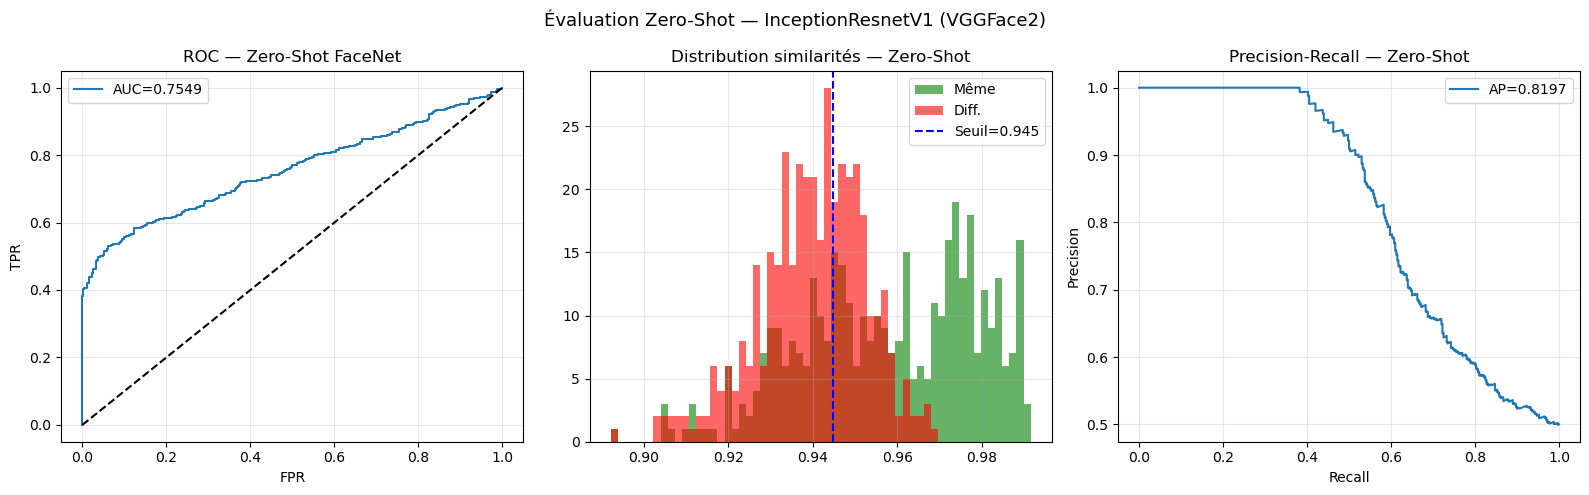

Sauvegardé : zeroshot_eval.png


In [17]:
# ── Visualisation zero-shot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
fpr_zs, tpr_zs, _ = roc_curve(labels_eval_zs, sims_zs)
axes[0].plot(fpr_zs, tpr_zs, label=f'AUC={auc_roc_zs:.4f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title('ROC — Zero-Shot FaceNet')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Distributions
bins = np.linspace(sims_zs.min(), sims_zs.max(), 60)
axes[1].hist(sims_zs[labels_eval_zs==1], bins=bins, alpha=0.6, label='Même', color='green')
axes[1].hist(sims_zs[labels_eval_zs==0], bins=bins, alpha=0.6, label='Diff.', color='red')
axes[1].axvline(thr_zs, color='blue', linestyle='--', label=f'Seuil={thr_zs:.3f}')
axes[1].set_title('Distribution similarités — Zero-Shot')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Precision-Recall
prec_zs, rec_zs, _ = precision_recall_curve(labels_eval_zs, sims_zs)
axes[2].plot(rec_zs, prec_zs, label=f'AP={auc_pr_zs:.4f}')
axes[2].set_title('Precision-Recall — Zero-Shot')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Évaluation Zero-Shot — InceptionResnetV1 (VGGFace2)', fontsize=13)
plt.tight_layout()
plt.savefig('zeroshot_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : zeroshot_eval.png')


## 6. Fine-Tuning avec Triplet Loss (optionnel)

Si le zero-shot est déjà excellent (AUC > 0.90), le fine-tuning apportera des gains marginaux.
Si AUC < 0.85, le fine-tuning est fortement recommandé.
Mets `FINE_TUNE = False` dans la config pour sauter cette section.


In [18]:
# ── Dataset PyTorch pour les triplets ────────────────────────────────────────
class TripletDataset(Dataset):
    def __init__(self, triplets, augment=False):
        self.triplets = triplets
        self.augment  = augment

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        anchor_path, pos_path, neg_path = self.triplets[idx]
        anchor  = torch.tensor(load_image_facenet(anchor_path,  augment=self.augment))
        positive= torch.tensor(load_image_facenet(pos_path,     augment=self.augment))
        negative= torch.tensor(load_image_facenet(neg_path,     augment=self.augment))
        return anchor, positive, negative


# ── Hard negative mining (identique à V4, mais en PyTorch-friendly) ─────────
def build_identity_index(df):
    grouped = {}
    for pid, grp in df.groupby('person_id'):
        if len(grp) >= 2:
            grouped[pid] = grp['filepath'].tolist()
    return grouped


@torch.no_grad()
def get_prototypes(df, model, batch_size=32):
    """Embedding du premier portrait de chaque identité (pour le mining)."""
    proto_rows = (df.sort_values(['person_id','photo_num'])
                   .groupby('person_id').head(1).reset_index(drop=True))
    fps = proto_rows['filepath'].tolist()
    model.eval()
    embs = []
    for i in range(0, len(fps), batch_size):
        batch = fps[i:i+batch_size]
        imgs  = torch.tensor(np.array([load_image_facenet(p) for p in batch]),
                             dtype=torch.float32).to(DEVICE)
        embs.append(model(imgs).cpu().numpy())
    embs = np.vstack(embs)
    return {pid: emb for pid, emb in zip(proto_rows['person_id'].tolist(), embs)}


def compute_hard_map(protos, k=MINING_K):
    ids = list(protos.keys())
    mat = np.stack([protos[pid] for pid in ids])
    sims = mat @ mat.T
    np.fill_diagonal(sims, -1.0)
    hard_map = {}
    for idx, pid in enumerate(ids):
        order = np.argsort(-sims[idx])
        hard_map[pid] = [ids[j] for j in order[:k] if sims[idx,j] > -0.5]
    return hard_map


def create_triplets(df, n_triplets=4000, seed=SEED, hard_map=None, hard_ratio=0.4):
    rng = np.random.default_rng(seed)
    id_index = build_identity_index(df)
    pids = np.array(sorted(id_index.keys()))
    triplets = []
    for _ in range(n_triplets):
        anchor_id = int(rng.choice(pids))
        pos_imgs  = id_index[anchor_id]
        anc, pos  = rng.choice(pos_imgs, size=2, replace=False)
        if hard_map and anchor_id in hard_map and len(hard_map[anchor_id]) > 0 and rng.random() < hard_ratio:
            neg_id = int(rng.choice(hard_map[anchor_id]))
        else:
            neg_pool = pids[pids != anchor_id]
            neg_id   = int(rng.choice(neg_pool))
        neg = str(rng.choice(id_index[neg_id]))
        triplets.append([anc, pos, neg])
    return np.array(triplets, dtype=object)


if FINE_TUNE:
    print('Calcul des prototypes pour le hard negative mining...')
    protos_train = get_prototypes(df_train_split, model)
    protos_val   = get_prototypes(df_val_split,   model)

    hard_map_train = compute_hard_map(protos_train, k=MINING_K)
    hard_map_val   = compute_hard_map(protos_val,   k=max(2, MINING_K//2))

    triplets_train = create_triplets(df_train_split, TRAIN_TRIPLETS, SEED,
                                     hard_map_train, HARD_RATIO_TRAIN)
    triplets_val   = create_triplets(df_val_split,   VAL_TRIPLETS,   SEED+1,
                                     hard_map_val,   HARD_RATIO_TRAIN)

    print(f'Triplets train : {len(triplets_train)}  | val : {len(triplets_val)}')
else:
    print('FINE_TUNE=False — skip.')


Calcul des prototypes pour le hard negative mining...
Triplets train : 8000  | val : 2000


In [19]:
def triplet_loss_fn(anchor, positive, negative, margin=TRIPLET_MARGIN):
    """Triplet Loss sur embeddings L2-normalisés."""
    pos_dist = F.pairwise_distance(anchor, positive, p=2)
    neg_dist = F.pairwise_distance(anchor, negative, p=2)
    loss = F.relu(pos_dist - neg_dist + margin)
    return loss.mean()


def triplet_accuracy_fn(anchor, positive, negative):
    """% de triplets où anchor est plus proche de positive que de negative."""
    pos_sim = (anchor * positive).sum(dim=1)
    neg_sim = (anchor * negative).sum(dim=1)
    return (pos_sim > neg_sim).float().mean().item()


def run_epoch(model, loader, optimizer=None, phase='train'):
    is_train = phase == 'train'
    model.train(is_train)
    total_loss, total_acc, n_batches = 0.0, 0.0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for anchors, positives, negatives in loader:
            anchors   = anchors.to(DEVICE)
            positives = positives.to(DEVICE)
            negatives = negatives.to(DEVICE)

            emb_a = model(anchors)
            emb_p = model(positives)
            emb_n = model(negatives)

            loss = triplet_loss_fn(emb_a, emb_p, emb_n)
            acc  = triplet_accuracy_fn(emb_a, emb_p, emb_n)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_acc  += acc
            n_batches  += 1

    return total_loss / max(n_batches, 1), total_acc / max(n_batches, 1)


if FINE_TUNE:
    train_ds = TripletDataset(triplets_train, augment=True)
    val_ds   = TripletDataset(triplets_val,   augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

    # ── Phase 1 : backbone gelé, seule la tête apprend ───────────────────────
    print('═' * 60)
    print('Phase 1 : Fine-tuning de la tête (backbone gelé)')
    print('═' * 60)

    optimizer1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=FT_LR_FROZEN
    )
    scheduler1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer1, mode='min', factor=0.5, patience=2
    )

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_loss = float('inf')

    for epoch in range(1, FT_EPOCHS_FROZEN + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer1, 'train')
        vl_loss, vl_acc = run_epoch(model, val_loader,   None,       'val')
        scheduler1.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        print(f'Epoch {epoch:2d}/{FT_EPOCHS_FROZEN}  '
              f'loss={tr_loss:.4f}/{vl_loss:.4f}  acc={tr_acc:.3f}/{vl_acc:.3f}')

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            torch.save(model.state_dict(), 'best_facenet_phase1.pt')
            print('  → Meilleur modèle sauvegardé')

    model.load_state_dict(torch.load('best_facenet_phase1.pt'))
    print('Phase 1 terminée.')
else:
    print('FINE_TUNE=False — skip.')


════════════════════════════════════════════════════════════
Phase 1 : Fine-tuning de la tête (backbone gelé)
════════════════════════════════════════════════════════════
Epoch  1/5  loss=0.1706/0.1764  acc=0.610/0.636
  → Meilleur modèle sauvegardé
Epoch  2/5  loss=0.1592/0.1754  acc=0.636/0.627
  → Meilleur modèle sauvegardé
Epoch  3/5  loss=0.1591/0.1718  acc=0.643/0.632
  → Meilleur modèle sauvegardé
Epoch  4/5  loss=0.1555/0.1782  acc=0.648/0.621
Epoch  5/5  loss=0.1566/0.1764  acc=0.648/0.627
Phase 1 terminée.


In [20]:
if FINE_TUNE:
    # ── Phase 2 : dégel des dernières couches du backbone ─────────────────────
    print('═' * 60)
    print(f'Phase 2 : Fine-tuning backbone (derniers {FT_UNFREEZE_LAST_N} blocs)')
    print('═' * 60)

    model.unfreeze_last_n_blocks(FT_UNFREEZE_LAST_N)

    optimizer2 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=FT_LR_UNFREEZE
    )
    scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer2, mode='min', factor=0.5, patience=3
    )

    best_val_loss = float('inf')
    patience_count = 0
    PATIENCE = 5

    phase2_history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

    for epoch in range(1, FT_EPOCHS_UNFREEZE + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer2, 'train')
        vl_loss, vl_acc = run_epoch(model, val_loader,   None,       'val')
        scheduler2.step(vl_loss)

        phase2_history['train_loss'].append(tr_loss)
        phase2_history['val_loss'].append(vl_loss)
        phase2_history['train_acc'].append(tr_acc)
        phase2_history['val_acc'].append(vl_acc)

        print(f'Epoch {epoch:2d}/{FT_EPOCHS_UNFREEZE}  '
              f'loss={tr_loss:.4f}/{vl_loss:.4f}  acc={tr_acc:.3f}/{vl_acc:.3f}')

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            patience_count = 0
            torch.save(model.state_dict(), 'best_facenet_final.pt')
            print('  → Meilleur modèle sauvegardé')
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f'Early stopping à l\'époque {epoch}')
                break

    model.load_state_dict(torch.load('best_facenet_final.pt'))
    print('Phase 2 terminée.')

    # Fusionner les historiques
    for k in history:
        history[k] += phase2_history[k]
else:
    print('FINE_TUNE=False — skip.')


════════════════════════════════════════════════════════════
Phase 2 : Fine-tuning backbone (derniers 5 blocs)
════════════════════════════════════════════════════════════
Paramètres entraînables : 9,087,104 / 28,075,063  (32.4%)
Epoch  1/10  loss=0.1526/0.1677  acc=0.661/0.645
  → Meilleur modèle sauvegardé
Epoch  2/10  loss=0.1452/0.1690  acc=0.678/0.646
Epoch  3/10  loss=0.1413/0.1659  acc=0.696/0.659
  → Meilleur modèle sauvegardé
Epoch  4/10  loss=0.1356/0.1703  acc=0.707/0.649
Epoch  5/10  loss=0.1307/0.1727  acc=0.715/0.627
Epoch  6/10  loss=0.1269/0.1688  acc=0.723/0.658
Epoch  7/10  loss=0.1211/0.1696  acc=0.737/0.646
Epoch  8/10  loss=0.1121/0.1695  acc=0.762/0.652
Early stopping à l'époque 8
Phase 2 terminée.


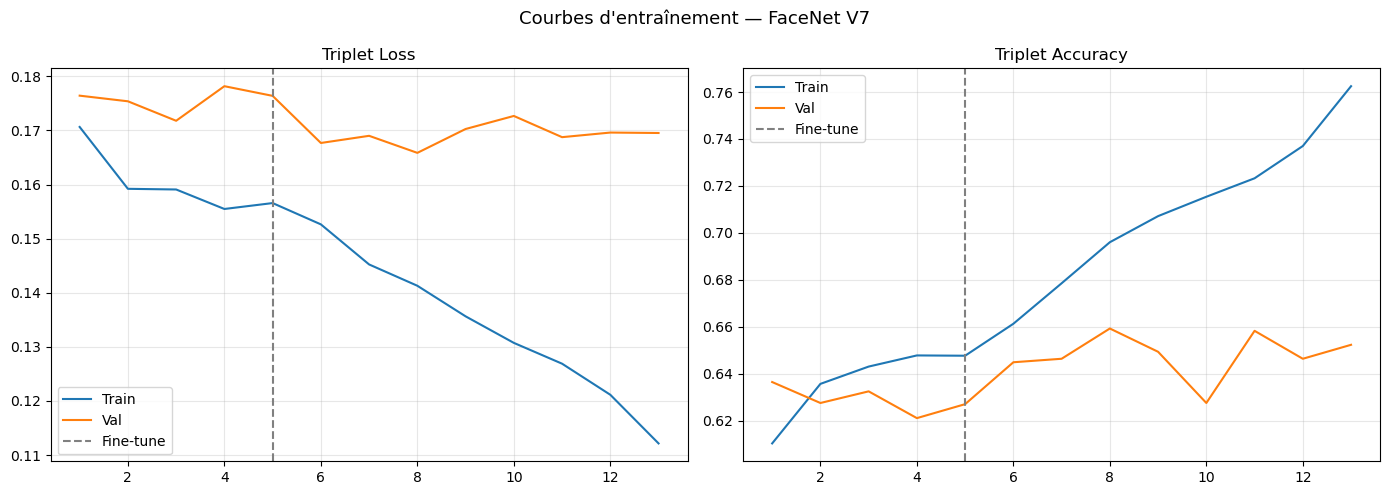

In [21]:
if FINE_TUNE:
    # ── Courbes d'entraînement ─────────────────────────────────────────────────
    phase2_start = FT_EPOCHS_FROZEN
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history['train_loss'], label='Train')
    ax1.plot(epochs, history['val_loss'],   label='Val')
    ax1.axvline(phase2_start, color='gray', linestyle='--', label='Fine-tune')
    ax1.set_title('Triplet Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['train_acc'], label='Train')
    ax2.plot(epochs, history['val_acc'],   label='Val')
    ax2.axvline(phase2_start, color='gray', linestyle='--', label='Fine-tune')
    ax2.set_title('Triplet Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.suptitle('Courbes d\'entraînement — FaceNet V7', fontsize=13)
    plt.tight_layout()
    plt.savefig('training_curves_v7.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('FINE_TUNE=False — skip.')


## 7. Calibration du Seuil Final


In [22]:
print('Extraction des embeddings de validation (avec TTA)...')
val_embs = get_embeddings(df_val_split['filepath'].values, model, use_tta=True)
emb_dict = dict(zip(df_val_split['filepath'].values, val_embs))

print('Création des paires équilibrées...')
pairs_val, labels_val = create_pairs(df_val_split, seed=SEED + 999)

optimal_threshold, roc_auc, pr_auc, f1_best, val_sims, labels_eval = calibrate_threshold(
    pairs_val, labels_val, emb_dict
)

print(f'\n── Métriques finales ──────────────────────────────────────')
print(f'AUC-ROC        : {roc_auc:.4f}')
print(f'AUC-PR         : {pr_auc:.4f}')
print(f'Seuil F1-opt   : {optimal_threshold:.4f}  (F1={f1_best:.3f})')

val_preds = (val_sims >= optimal_threshold).astype(int)
print('\nClassification Report (validation finale) :')
print(classification_report(labels_eval, val_preds, target_names=['Diff.', 'Meme'], zero_division=0))

# ── Comparaison Zero-Shot vs Fine-tuned ───────────────────────────────────
if FINE_TUNE:
    print('\n── Comparaison Zero-Shot vs Fine-tuned ────────────────────')
    print(f'  Zero-Shot  : AUC-ROC={auc_roc_zs:.4f}  AUC-PR={auc_pr_zs:.4f}  F1={f1_zs:.3f}')
    print(f'  Fine-tuned : AUC-ROC={roc_auc:.4f}  AUC-PR={pr_auc:.4f}  F1={f1_best:.3f}')


Extraction des embeddings de validation (avec TTA)...


Embeddings: 100%|██████████| 25/25 [00:16<00:00,  1.55it/s]

Création des paires équilibrées...
  Positifs : 400 | Négatifs cible (équilibré) : 400

── Métriques finales ──────────────────────────────────────
AUC-ROC        : 0.7156
AUC-PR         : 0.7432
Seuil F1-opt   : 0.4046  (F1=0.685)

Classification Report (validation finale) :
              precision    recall  f1-score   support

       Diff.       0.71      0.36      0.48       400
        Meme       0.57      0.85      0.69       400

    accuracy                           0.61       800
   macro avg       0.64      0.61      0.58       800
weighted avg       0.64      0.61      0.58       800


── Comparaison Zero-Shot vs Fine-tuned ────────────────────
  Zero-Shot  : AUC-ROC=0.7549  AUC-PR=0.8197  F1=0.687
  Fine-tuned : AUC-ROC=0.7156  AUC-PR=0.7432  F1=0.685


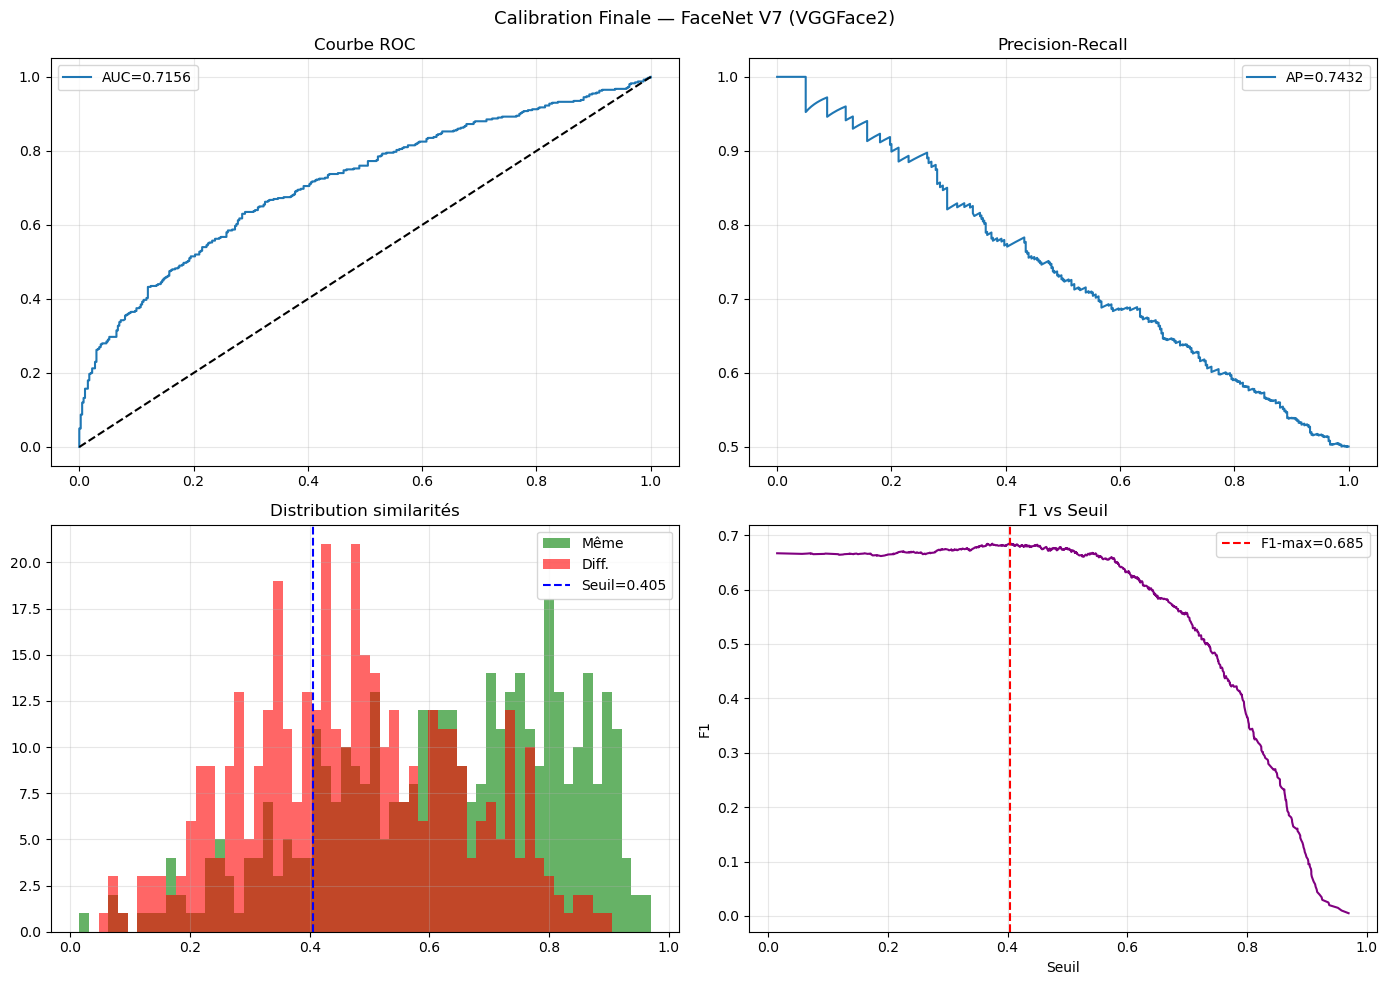

In [23]:
# ── Visualisation 4 graphiques ─────────────────────────────────────────────
fpr, tpr, _ = roc_curve(labels_eval, val_sims)
prec, rec, thr_pr = precision_recall_curve(labels_eval, val_sims)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(fpr, tpr, label=f'AUC={roc_auc:.4f}')
axes[0,0].plot([0,1],[0,1],'k--')
axes[0,0].set_title('Courbe ROC'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(rec, prec, label=f'AP={pr_auc:.4f}')
axes[0,1].set_title('Precision-Recall'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

bins = np.linspace(val_sims.min(), val_sims.max(), 60)
axes[1,0].hist(val_sims[labels_eval==1], bins=bins, alpha=0.6, label='Même', color='green')
axes[1,0].hist(val_sims[labels_eval==0], bins=bins, alpha=0.6, label='Diff.', color='red')
axes[1,0].axvline(optimal_threshold, color='blue', linestyle='--', label=f'Seuil={optimal_threshold:.3f}')
axes[1,0].set_title('Distribution similarités'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(thr_pr, f1s, color='purple')
axes[1,1].axvline(optimal_threshold, color='red', linestyle='--', label=f'F1-max={f1_best:.3f}')
axes[1,1].set_xlabel('Seuil'); axes[1,1].set_ylabel('F1')
axes[1,1].set_title('F1 vs Seuil'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Calibration Finale — FaceNet V7 (VGGFace2)', fontsize=13)
plt.tight_layout()
plt.savefig('calibration_v7.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Prédiction sur le Test Set


In [24]:
def predict_test_set(test_path, model, threshold, use_tta=True, sim_upper=0.999):
    """
    Prédit les paires de même identité.
    - threshold  : seuil bas (F1-optimal)
    - sim_upper  : seuil haut anti-doublons (Sim=1.000 = même image)
    """
    test_images, _ = _list_valid_jpgs(test_path)
    print(f'Images de test : {len(test_images)}')

    df_test = pd.DataFrame({
        'filepath': [str(p) for p in test_images],
        'filename': [p.name for p in test_images],
    })

    print('Extraction des embeddings test...')
    test_embs = get_embeddings(df_test['filepath'].values, model, use_tta=use_tta)

    # Matrice de similarité (dot product = cosine car L2-normalisé)
    sim_matrix = test_embs @ test_embs.T

    matches = []
    dups_skipped = 0
    n = len(df_test)
    for i in range(n):
        for j in range(i + 1, n):
            sim = float(sim_matrix[i, j])
            if sim > sim_upper:
                dups_skipped += 1
                continue
            if sim >= threshold:
                matches.append({
                    'image1':     df_test.iloc[i]['filename'],
                    'image2':     df_test.iloc[j]['filename'],
                    'similarity': round(sim, 5),
                    'is_match':   1,
                })

    print(f'Quasi-doublons ignorés (sim > {sim_upper}) : {dups_skipped}')
    print(f'Paires matchées retenues                   : {len(matches)}')
    return pd.DataFrame(matches), df_test


matches_df, df_test = predict_test_set(
    TEST_PATH, model,
    threshold=optimal_threshold,
    use_tta=True,
    sim_upper=0.999,
)
print(matches_df.head(10))


Images de test : 2000
Extraction des embeddings test...


Embeddings: 100%|██████████| 63/63 [00:47<00:00,  1.33it/s]


Quasi-doublons ignorés (sim > 0.999) : 1219
Paires matchées retenues                   : 1339607
       image1      image2  similarity  is_match
0  3000_0.jpg  3001_1.jpg     0.57420         1
1  3000_0.jpg  3002_1.jpg     0.44730         1
2  3000_0.jpg  3004_0.jpg     0.83655         1
3  3000_0.jpg  3004_1.jpg     0.49835         1
4  3000_0.jpg  3006_1.jpg     0.44801         1
5  3000_0.jpg  3007_1.jpg     0.70966         1
6  3000_0.jpg  3009_0.jpg     0.56517         1
7  3000_0.jpg  3010_0.jpg     0.48060         1
8  3000_0.jpg  3013_1.jpg     0.61368         1
9  3000_0.jpg  3014_0.jpg     0.44635         1


## 9. Fichier de Soumission


In [25]:
matches_df.to_csv('tache1_submission_v7.csv', index=False)
print('Soumission sauvegardée : tache1_submission_v7.csv')
print(f'Paires soumises          : {len(matches_df)}')
print(f'Seuil bas (F1-optimal)   : {optimal_threshold:.4f}')
print(f'Seuil haut (anti-dedup)  : 0.999')
print(f'AUC-ROC                  : {roc_auc:.4f}')
print(f'AUC-PR                   : {pr_auc:.4f}')
print(f'Backbone                 : InceptionResnetV1 (VGGFace2)')
print(f'Fine-tuning              : {FINE_TUNE}')
print(f'TTA vues                 : {TTA_N_VIEWS}')


Soumission sauvegardée : tache1_submission_v7.csv
Paires soumises          : 1339607
Seuil bas (F1-optimal)   : 0.4046
Seuil haut (anti-dedup)  : 0.999
AUC-ROC                  : 0.7156
AUC-PR                   : 0.7432
Backbone                 : InceptionResnetV1 (VGGFace2)
Fine-tuning              : True
TTA vues                 : 3


## 10. Visualisation des Top Paires Matchées


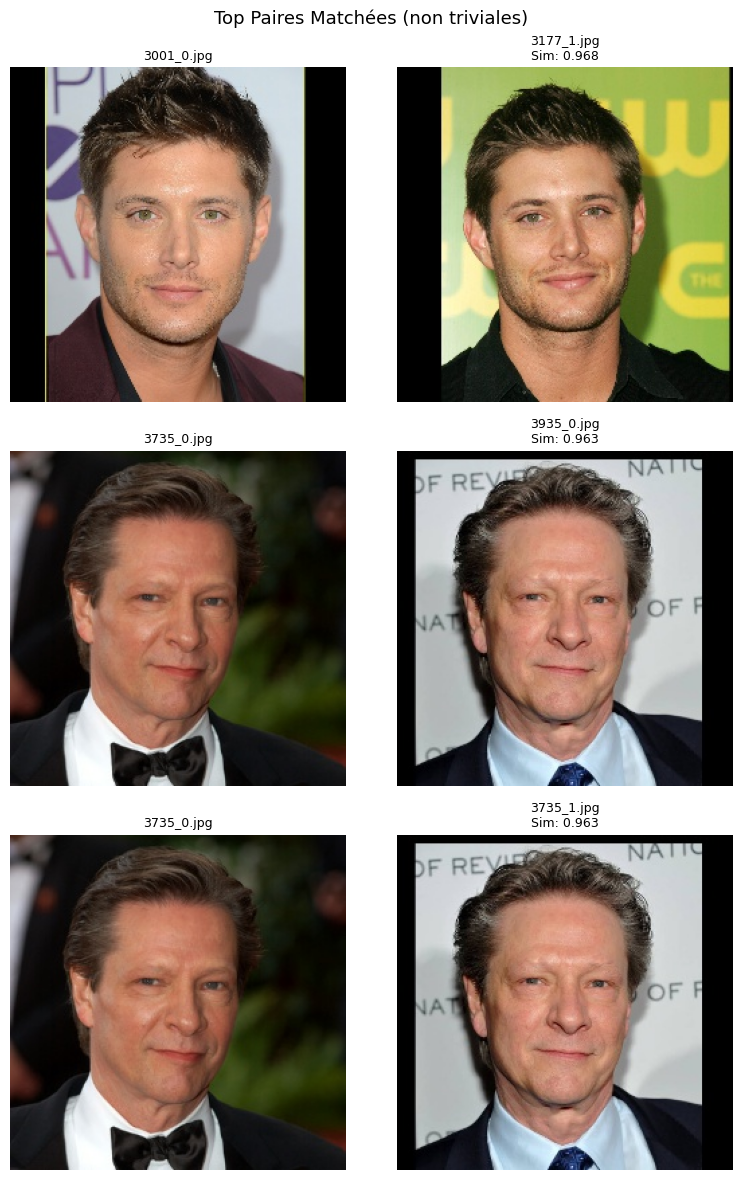

Sauvegardé : matches_v7.png


In [26]:
if len(matches_df) > 0:
    # Exclure les top paires triviales (sim = 1.000) → prendre les paires dans 0.90-0.99
    sample_df = matches_df[
        (matches_df['similarity'] < 0.999) &
        (matches_df['similarity'] >= optimal_threshold)
    ].sort_values('similarity', ascending=False).head(3)

    if len(sample_df) == 0:
        sample_df = matches_df.sort_values('similarity', ascending=False).head(3)

    fig, axes = plt.subplots(len(sample_df), 2, figsize=(8, 4 * len(sample_df)))
    if len(sample_df) == 1:
        axes = np.expand_dims(axes, 0)

    for idx, (_, row) in enumerate(sample_df.iterrows()):
        for col, img_name in enumerate([row['image1'], row['image2']]):
            img = cv2.imread(str(TEST_PATH / img_name))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[idx, col].imshow(img)
            else:
                axes[idx, col].text(0.5, 0.5, 'Erreur', ha='center', va='center')
            label = img_name if col == 0 else f'{img_name}\nSim: {row["similarity"]:.3f}'
            axes[idx, col].set_title(label, fontsize=9)
            axes[idx, col].axis('off')

    plt.suptitle('Top Paires Matchées (non triviales)', fontsize=13)
    plt.tight_layout()
    plt.savefig('matches_v7.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sauvegardé : matches_v7.png')
else:
    print('Aucune paire trouvée — baisse le seuil ou vérifie le modèle.')
